<a href="https://colab.research.google.com/github/Mzark15/KISAN-MITRA---Rice-Paddy-Leaf-Disease-Classifier/blob/mayur-staging/Kisan_Mitra_Rice_Disease_Classifier_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌾 Kisan Mitra — Rice Disease Classifier (v2, improved)
This is the cleaned-up version with the accuracy fixes built in:
- **Class weights** — makes the model take the rarer diseases seriously.
- **Gentler fine-tuning** — unfreezes fewer layers, trains longer, avoids the crash we saw.
- **Longer head training** — the head was still improving when it stopped last time.

**How to run:** Runtime → Change runtime type → **GPU**. Then run every cell top to bottom (Shift+Enter). Don't skip around.


## 1. Kaggle login
Paste your **new** token (KGAT_...) in the hidden box. You re-do this each fresh session because Colab wipes it.

In [ ]:
import os, getpass
token = getpass.getpass("Paste your Kaggle API token (KGAT_...): ")
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
with open(os.path.expanduser("~/.kaggle/access_token"), "w") as f:
    f.write(token.strip())
os.chmod(os.path.expanduser("~/.kaggle/access_token"), 0o600)
print("Kaggle token set up ✓")

## 2. Download the dataset
~1 GB, takes ~15 seconds. Re-run each session (Colab wipes downloads).

In [ ]:
import kagglehub, os
path = kagglehub.competition_download('paddy-disease-classification')
DATA_DIR = os.path.join(path, "train_images")
print("Data at:", DATA_DIR)
print("Disease folders:")
for d in sorted(os.listdir(DATA_DIR)):
    print(f"   {d}: {len(os.listdir(os.path.join(DATA_DIR, d)))} images")

## 3. Settings

In [ ]:
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
EPOCHS_HEAD = 25   # longer head training
EPOCHS_FINE = 15    # give fine-tuning room to work
SEED = 123
# DATA_DIR is already set in the cell above.

## 4. Load the images (80% train / 20% validation)

In [ ]:
import tensorflow as tf

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset="training",
    seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset="validation",
    seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print("Classes:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

## 5. Class weights — the fix for weak classes
Rarer diseases (like bacterial_leaf_blight) get a higher weight, so the model pays more attention to them instead of ignoring them.

In [ ]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

print("Counting images per class (takes a minute)...")
labels_all = [int(l.numpy()) for _, labels in train_ds.unbatch() for l in [labels]]

weights = compute_class_weight("balanced", classes=np.arange(NUM_CLASSES), y=np.array(labels_all))
class_weight = {i: float(w) for i, w in enumerate(weights)}
for i, name in enumerate(class_names):
    print(f"   {name}: weight {class_weight[i]:.2f}")

Counting images per class (takes a minute)...
   bacterial_leaf_blight: weight 2.18
   bacterial_leaf_streak: weight 2.70
   bacterial_panicle_blight: weight 2.97
   blast: weight 0.61
   brown_spot: weight 1.08
   dead_heart: weight 0.73
   downy_mildew: weight 1.64
   hispa: weight 0.65
   normal: weight 0.60
   tungro: weight 0.94


## 6. Data augmentation — survive real-world photos

In [ ]:
from tensorflow.keras import layers
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15),
], name="data_augmentation")

## 7. Build the model (MobileNetV2 transfer learning)

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import models

base_model = MobileNetV2(input_shape=IMG_SIZE + (3,), include_top=False, weights="imagenet")
base_model.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
model = models.Model(inputs, outputs)

model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
print("Model built. Trainable params are small (head only) - that's correct.")

Model built. Trainable params are small (head only) - that's correct.


## 8. Phase 1 — train the head (with class weights)

In [ ]:
history_head = model.fit(
    train_ds, validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    class_weight=class_weight)

Epoch 1/25
261/261 ━━━━━━━━━━━━━━━━━━━━ 30s 97ms/step - accuracy: 0.3082 - loss: 1.9142 - val_accuracy: 0.4690 - val_loss: 1.5609
Epoch 2/25
261/261 ━━━━━━━━━━━━━━━━━━━━ 17s 65ms/step - accuracy: 0.4313 - loss: 1.5746 - val_accuracy: 0.4815 - val_loss: 1.4733
Epoch 3/25
261/261 ━━━━━━━━━━━━━━━━━━━━ 17s 66ms/step - accuracy: 0.4780 - loss: 1.4406 - val_accuracy: 0.4695 - val_loss: 1.5016
Epoch 4/25
261/261 ━━━━━━━━━━━━━━━━━━━━ 17s 65ms/step - accuracy: 0.5038 - loss: 1.3662 - val_accuracy: 0.4652 - val_loss: 1.5145
Epoch 5/25
261/261 ━━━━━━━━━━━━━━━━━━━━ 17s 65ms/step - accuracy: 0.5330 - loss: 1.2818 - val_accuracy: 0.5305 - val_loss: 1.3312
Epoch 6/25
261/261 ━━━━━━━━━━━━━━━━━━━━ 17s 66ms/step - accuracy: 0.5518 - loss: 1.2444 - val_accuracy: 0.5502 - val_loss: 1.3172
Epoch 7/25
261/261 ━━━━━━━━━━━━━━━━━━━━ 17s 67ms/step - accuracy: 0.5572 - loss: 1.2214 - val_accuracy: 0.5353 - val_loss: 1.3686
Epoch 8/25
261/261 ━━━━━━━━━━━━━━━━━━━━ 21s 69ms/step - accuracy: 0.5703 - loss: 1.1468 - 

## 9. Phase 2 — gentle fine-tuning (with class weights)
**The key fix:** unfreeze only the last **20** layers (not 40) and train longer with a tiny learning rate. This should avoid the accuracy crash from last time.

In [ ]:
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Stop automatically when validation stops improving, keep the best weights
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=6,               # wait 6 epochs for improvement before stopping
    restore_best_weights=True # roll back to the best epoch
)

history_fine = model.fit(
    train_ds, validation_data=val_ds,
    epochs=40,                # a high ceiling — early stopping ends it sooner
    class_weight=class_weight,
    callbacks=[early_stop])

Epoch 1/40
261/261 ━━━━━━━━━━━━━━━━━━━━ 31s 88ms/step - accuracy: 0.3973 - loss: 1.9645 - val_accuracy: 0.6276 - val_loss: 1.0760
Epoch 2/40
261/261 ━━━━━━━━━━━━━━━━━━━━ 21s 81ms/step - accuracy: 0.4528 - loss: 1.4886 - val_accuracy: 0.6377 - val_loss: 1.0671
Epoch 3/40
261/261 ━━━━━━━━━━━━━━━━━━━━ 21s 80ms/step - accuracy: 0.4956 - loss: 1.3563 - val_accuracy: 0.6458 - val_loss: 1.0574
Epoch 4/40
261/261 ━━━━━━━━━━━━━━━━━━━━ 21s 81ms/step - accuracy: 0.5383 - loss: 1.2515 - val_accuracy: 0.6482 - val_loss: 1.0756
Epoch 5/40
261/261 ━━━━━━━━━━━━━━━━━━━━ 21s 82ms/step - accuracy: 0.5623 - loss: 1.1706 - val_accuracy: 0.6487 - val_loss: 1.0589
Epoch 6/40
261/261 ━━━━━━━━━━━━━━━━━━━━ 21s 81ms/step - accuracy: 0.5794 - loss: 1.1049 - val_accuracy: 0.6482 - val_loss: 1.0612
Epoch 7/40
261/261 ━━━━━━━━━━━━━━━━━━━━ 21s 80ms/step - accuracy: 0.6014 - loss: 1.0614 - val_accuracy: 0.6478 - val_loss: 1.0832
Epoch 8/40
261/261 ━━━━━━━━━━━━━━━━━━━━ 21s 81ms/step - accuracy: 0.6098 - loss: 1.0270 - 

## 10. Accuracy graph

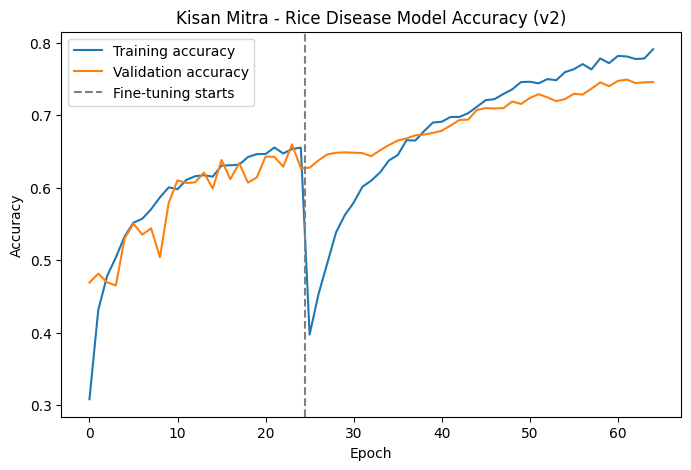

In [ ]:
import matplotlib.pyplot as plt
acc     = history_head.history["accuracy"] + history_fine.history["accuracy"]
val_acc = history_head.history["val_accuracy"] + history_fine.history["val_accuracy"]
plt.figure(figsize=(8,5))
plt.plot(acc, label="Training accuracy")
plt.plot(val_acc, label="Validation accuracy")
plt.axvline(EPOCHS_HEAD-0.5, color="grey", linestyle="--", label="Fine-tuning starts")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend()
plt.title("Kisan Mitra - Rice Disease Model Accuracy (v2)")
plt.show()

## 11. Per-disease report — the honest scorecard

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
y_true, y_pred = [], []
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy()); y_pred.extend(np.argmax(preds, axis=1))
print(classification_report(y_true, y_pred, target_names=class_names))
print("Confusion matrix (rows=actual, cols=guess):")
print(confusion_matrix(y_true, y_pred))

                          precision    recall  f1-score   support

   bacterial_leaf_blight       0.67      0.75      0.71        97
   bacterial_leaf_streak       0.55      0.96      0.70        72
bacterial_panicle_blight       0.67      0.96      0.79        57
                   blast       0.85      0.68      0.75       363
              brown_spot       0.53      0.82      0.65       191
              dead_heart       0.96      0.71      0.82       307
            downy_mildew       0.58      0.89      0.70       112
                   hispa       0.77      0.70      0.73       316
                  normal       0.90      0.76      0.82       365
                  tungro       0.77      0.71      0.74       201

                accuracy                           0.75      2081
               macro avg       0.73      0.79      0.74      2081
            weighted avg       0.79      0.75      0.76      2081

Confusion matrix (rows=actual, cols=guess):
[[ 73   4   0   2   7   0   4

## 12. Save the model (for Raj's backend)

In [ ]:
SAVE_DIR = "/content/drive/MyDrive/kisan_mitra/model"
os.makedirs(SAVE_DIR, exist_ok=True)
model.save(os.path.join(SAVE_DIR, "rice_disease_model.keras"))
with open(os.path.join(SAVE_DIR, "class_names.txt"), "w") as f:
    f.write("\n".join(class_names))
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
with open(os.path.join(SAVE_DIR, "rice_disease_model.tflite"), "wb") as f:
    f.write(converter.convert())
print("Saved to", SAVE_DIR)

Saved artifact at '/tmp/tmpgaul8rdj'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_323')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  134768442616976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134768442614096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134768442616400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134768442612176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134768442615248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134768442614672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134768442617552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134768442615632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134768442615056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134768442616016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134760941

## 13. Test on one photo
Upload a rice leaf. Low confidence → the app should ask for a clearer photo, not guess.

In [ ]:
from google.colab import files
from tensorflow.keras.utils import load_img, img_to_array
uploaded = files.upload()
for filename in uploaded:
    arr = tf.expand_dims(img_to_array(load_img(filename, target_size=IMG_SIZE)), 0)
    pred = model.predict(arr, verbose=0)[0]
    best = int(np.argmax(pred)); conf = float(pred[best])*100
    print(f"{filename}: {class_names[best]} ({conf:.1f}% sure)")
    if conf < 60:
        print("   Low confidence -> ask for a clearer photo.")

Saving cochliobolus.jpg to cochliobolus (1).jpg
cochliobolus (1).jpg: bacterial_leaf_streak (58.5% sure)
   Low confidence -> ask for a clearer photo.


## 14. Mount Drive (run this once, early, so saving works)
> If step 12 fails saying Drive isn't mounted, run this then re-run step 12.

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

ValueError: Mountpoint must not already contain files

In [ ]:
import os
save_dir = "/content/drive/MyDrive/kisan_mitra/model"
print(os.listdir(save_dir))
# Expect: ['rice_disease_model.keras', 'class_names.txt', 'rice_disease_model.tflite']

['rice_disease_model.tflite', 'rice_disease_model.keras', 'class_names.txt']


In [ ]:
SAVE_DIR = "/content/drive/MyDrive/kisan_mitra/model"
model.save_weights(SAVE_DIR + "/rice_disease.weights.h5")
print("Weights saved. Download this file:", SAVE_DIR + "/rice_disease.weights.h5")

Weights saved. Download this file: /content/drive/MyDrive/kisan_mitra/model/rice_disease.weights.h5


In [ ]:
SAVE_DIR = "/content/drive/MyDrive/kisan_mitra/model"
model.save_weights(SAVE_DIR + "/rice_disease.weights.h5")
print("Saved:", SAVE_DIR + "/rice_disease.weights.h5")

Saved: /content/drive/MyDrive/kisan_mitra/model/rice_disease.weights.h5
